In [1]:

import os, re, glob, pickle
import numpy as np
import pandas as pd

from pathlib import Path
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.decomposition import PCA
from sklearn.ensemble import RandomForestClassifier
from sklearn.pipeline import Pipeline

print("Libraries imported successfully yay!")

Libraries imported successfully yay!


In [2]:
# Change this path if your folder is stored elsewhere
DATA_DIR = Path("CleanedKARDDataset/RealWorldCoordinates")  # change if needed

# Make sure the folder exists before continuing
assert DATA_DIR.exists(), f"Data dir not found: {DATA_DIR}"


# Collect all CSV files in the folder
files = sorted(glob.glob(str(DATA_DIR / "*.csv")))
print("Found files:", len(files))

# Preview first few file names
print(files[:3])

Found files: 180
['CleanedKARDDataset\\RealWorldCoordinates\\a01_s01_e01_realworld.csv', 'CleanedKARDDataset\\RealWorldCoordinates\\a01_s02_e01_realworld.csv', 'CleanedKARDDataset\\RealWorldCoordinates\\a01_s03_e01_realworld.csv']


In [3]:
# -------------------------------------------------------------
# 3. PARSE SEQUENCES INTO ARRAYS
# -------------------------------------------------------------
# Each CSV lists joint coordinates for multiple frames.
# Reconstructing the frames so each file becomes:
#     seq shape = (T, J, 3)
# where:
#   T = number of frames
#   J = number of joints
#   3 = x, y, z coordinates
# -------------------------------------------------------------

def parse_sequence(csv_path: str):
    """
    Convert a single CSV into a 3D numpy array [frames, joints, coords].
    'Head' rows are used to detect new frames in the CSV stream.
    Returns:
        seq  -> np.ndarray of shape (T, J, 3)
        joint_order -> list of joint names in consistent order
    """

    df = pd.read_csv(csv_path)
    frames = []     # stores frame DataFrames
    current = []    # collects rows for current frame

     # Every time we see a "Head" joint, assume a new frame begins
    for _, row in df.iterrows():
        if row['Joint'] == 'Head' and current:
            frames.append(pd.DataFrame(current))
            current = []
        current.append(row)
    if current:
        frames.append(pd.DataFrame(current))

    # Determine the joint order from the first valid frame
    joint_order = None
    for fr in frames:
        if 'Joint' in fr and fr['Joint'].nunique() >= 10:
            joint_order = list(fr['Joint'])
            break
    if joint_order is None:
        return None

     # Create a 3D array: time × joints × coordinates
    T = len(frames)
    J = len(joint_order)
    seq = np.full((T, J, 3), np.nan, dtype=float)

     # Fill sequence array with x,y,z coordinates for each joint per frame
    for t, fr in enumerate(frames):
        # Map each joint name → (x, y, z)
        name_to_xyz = {n: (x, y, z) for n, x, y, z in fr[['Joint', 'x', 'y', 'z']].itertuples(index=False)}
        for j, name in enumerate(joint_order):
            if name in name_to_xyz:
                seq[t, j, :] = name_to_xyz[name]
    return seq, joint_order

In [4]:
# -------------------------------------------------------------
# 4. PREPROCESS EACH SEQUENCE
# -------------------------------------------------------------
# To feed into ML, all sequences must have:
# - the same number of frames (resampling)
# - comparable scale (normalization)
# - dynamic info (velocities)
# -------------------------------------------------------------

def resample_sequence(seq: np.ndarray, target_T: int = 60) -> np.ndarray:
    """
    Resample sequence to a fixed number of frames (default 60)
    by linear interpolation along the time dimension.
    """
    T, J, C = seq.shape
    src_t = np.arange(T)
    dst_t = np.linspace(0, T - 1, target_T)
    out = np.empty((target_T, J, C), dtype=float)

    for j in range(J):
        for c in range(C):
            # Fill any missing (NaN) data before interpolation
            y = pd.Series(seq[:, j, c]).ffill().bfill().to_numpy()
            out[:, j, c] = np.interp(dst_t, src_t, y)
    return out


def root_center_normalize(seq: np.ndarray, joint_names: list, root_name: str = 'Torso') -> np.ndarray:
    """
    Center coordinates around the torso joint and scale
    by the median head-to-torso distance.
    """
    T, J, C = seq.shape
    # identify root and head joints (fallback to 0 if missing)
    root_idx = joint_names.index(root_name) if root_name in joint_names else 0
    head_idx = joint_names.index('Head') if 'Head' in joint_names else 0

    # Center by subtracting torso coordinates
    centered = seq - seq[:, [root_idx], :]

    # Compute typical human scale factor
    d = np.linalg.norm(centered[:, head_idx, :] - centered[:, root_idx, :], axis=1)
    scale = np.median(d) if np.isfinite(np.median(d)) and np.median(d) != 0 else 1.0

    return centered / scale


def make_features(seq: np.ndarray, include_velocity: bool = True) -> np.ndarray:
    """
    Convert 3D sequence into a 1D feature vector:
    - positions flattened across all frames and joints
    - optional velocities (differences between consecutive frames)
    """
    pos_flat = seq.reshape(-1)
    feats = [pos_flat]

    if include_velocity:
        vel = np.diff(seq, axis=0)
        feats.append(vel.reshape(-1))

    return np.concatenate(feats)

In [5]:
# -------------------------------------------------------------
# 5. BUILD FEATURE MATRIX X AND LABEL VECTOR y
# -------------------------------------------------------------
# For each CSV:
#   - Parse into sequence
#   - Resample to fixed 60 frames
#   - Normalize by torso & head distance
#   - Extract flattened features
#   - Derive label from filename prefix ("aXX")
# -------------------------------------------------------------

X, y = [], []

for f in files:
    parsed = parse_sequence(f)
    if parsed is None:
        continue
    seq, joint_names = parsed

    # Step 1: standardize frame length
    seq = resample_sequence(seq, target_T=60)

    # Step 2: normalize to remove global offset/scale
    seq = root_center_normalize(seq, joint_names)

    # Step 3: extract flattened features (positions + velocities)
    feats = make_features(seq, include_velocity=True)
    X.append(feats)

    # Step 4: extract action label from file name
    m = re.search(r'a(\d+)_', os.path.basename(f))
    label = f"a{m.group(1)}" if m else "unknown"
    y.append(label)

# Convert lists into NumPy arrays
X = np.stack(X)
y = np.array(y)

print("Feature matrix shape:", X.shape)
print("Labels shape:", y.shape)
print("Unique labels:", np.unique(y))

Feature matrix shape: (180, 4998)
Labels shape: (180,)
Unique labels: ['a01' 'a02' 'a03' 'a04' 'a05' 'a06' 'a07' 'a08' 'a09' 'a10' 'a11' 'a12'
 'a13' 'a14' 'a15' 'a16' 'a17' 'a18']


In [19]:
# -------------------------------------------------------------
# 6. LABEL ENCODING AND DATA SPLIT
# -------------------------------------------------------------
# Machine learning models require numerical labels.
# LabelEncoder maps each motion type string (a01, a02, ...)
# into an integer ID. We then split data 80/20 for training/testing.
# -------------------------------------------------------------

le = LabelEncoder()
y_enc = le.fit_transform(y)

# Split data, ensuring each class is proportionally represented
X_train, X_test, y_train, y_test = train_test_split(
    X, y_enc, test_size=0.2, stratify=y_enc, random_state=42
)

print(f"Train set: {X_train.shape}, Test set: {X_test.shape}")


Train set: (144, 4998), Test set: (36, 4998)


In [45]:
# -------------------------------------------------------------
# 8. MODEL 2: REDUCED FEATURE SET WITH PCA
# -------------------------------------------------------------
# PCA = Principal Component Analysis
# Reduces dimensionality by keeping only top components
# that explain most of the variance in the dataset.
# -------------------------------------------------------------

# Number of principal components must be ≤ min(samples-1, features)
from sklearn.metrics import accuracy_score
n_components = min(100, X_train.shape[0] - 1, X_train.shape[1])

clf_reduced = Pipeline([
    ('scaler', StandardScaler(with_mean=True)),
    ('pca', PCA(n_components=n_components, random_state=42)),
    ('rf', RandomForestClassifier(
        n_estimators=300,
        max_depth=None,
        n_jobs=-1,
        random_state=42
    ))
])

clf_reduced.fit(X_train, y_train)
print(f"Reduced feature model trained (PCA with {n_components} components).")
y_pred = clf_reduced.predict(X_test)
print("Accuracy:", accuracy_score(y_test, y_pred))

Reduced feature model trained (PCA with 100 components).
Accuracy: 0.08333333333333333


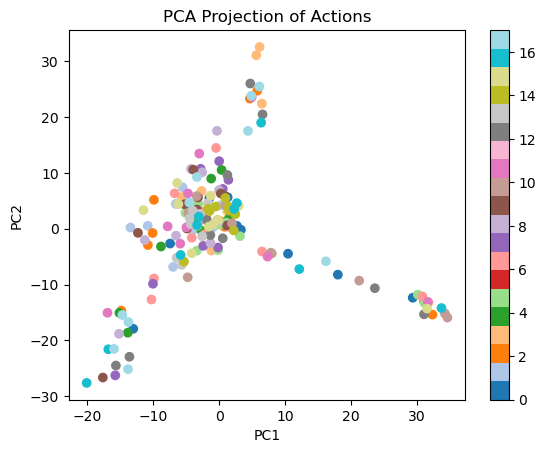

In [27]:
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt

pca = PCA(n_components=2)
X_pca = pca.fit_transform(X)

plt.scatter(X_pca[:,0], X_pca[:,1], c=y_enc, cmap='tab20')
plt.title("PCA Projection of Actions")
plt.xlabel("PC1"); plt.ylabel("PC2")
plt.colorbar()
plt.show()

Explained variance ratios: [0.05125792 0.04789087 0.04200902]


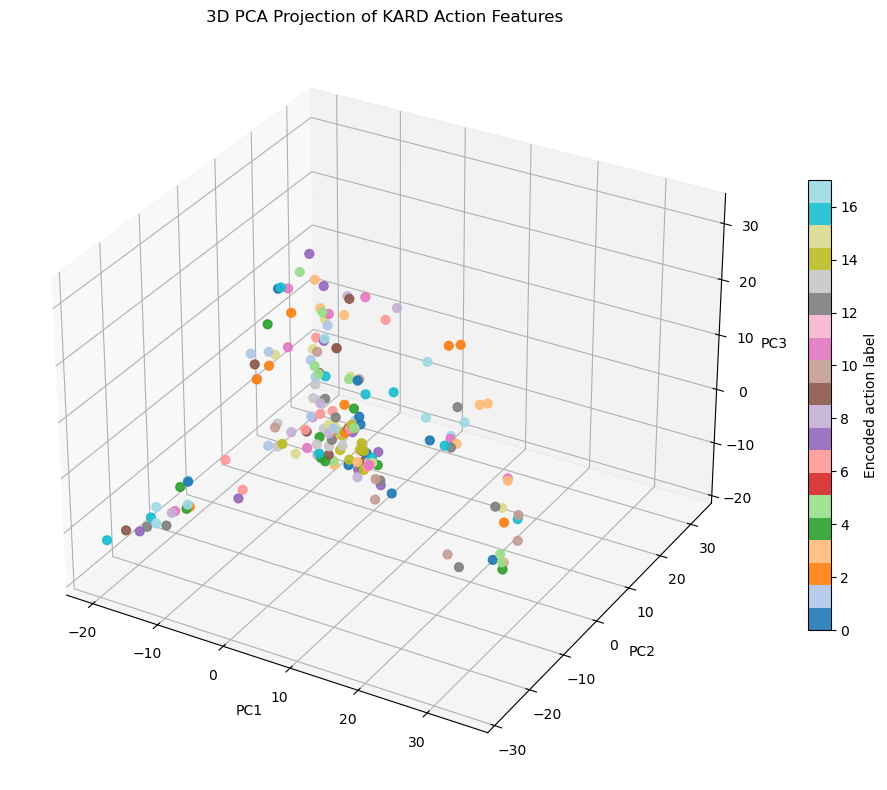

In [15]:
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA
from mpl_toolkits.mplot3d import Axes3D  # needed for 3D plots

# 1) Reduce 4998-D → 3 principal components
pca_3d = PCA(n_components=3)
X_pca_3d = pca_3d.fit_transform(X)   # X shape: (180, 4998)

print("Explained variance ratios:", pca_3d.explained_variance_ratio_)

# 2) Make a 3D scatter plot
fig = plt.figure(figsize=(10, 8))
ax = fig.add_subplot(111, projection='3d')

sc = ax.scatter(
    X_pca_3d[:, 0],
    X_pca_3d[:, 1],
    X_pca_3d[:, 2],
    c=y_enc,          # color by label
    cmap='tab20',
    s=40,
    alpha=0.9
)

ax.set_title("3D PCA Projection of KARD Action Features")
ax.set_xlabel("PC1")
ax.set_ylabel("PC2")
ax.set_zlabel("PC3")

# Optional: colorbar for classes
cbar = plt.colorbar(sc, ax=ax, shrink=0.6)
cbar.set_label("Encoded action label")

plt.tight_layout()
plt.show()


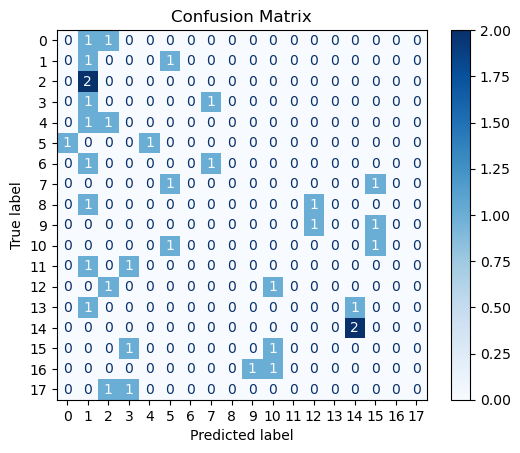

In [25]:
from sklearn.metrics import ConfusionMatrixDisplay

ConfusionMatrixDisplay.from_predictions(y_test, y_pred, cmap='Blues')
plt.title("Confusion Matrix")
plt.show()


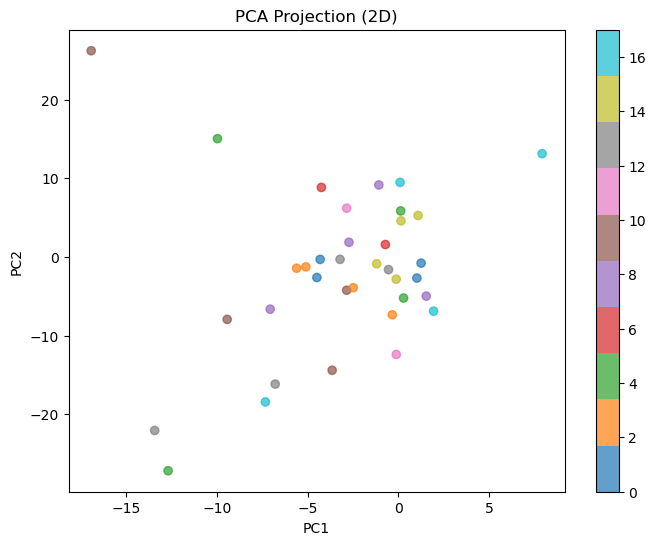

In [28]:
X_test_pca = clf_reduced.named_steps['pca'].transform(
    clf_reduced.named_steps['scaler'].transform(X_test)
)

plt.figure(figsize=(8,6))
plt.scatter(X_test_pca[:,0], X_test_pca[:,1], c=y_test, cmap='tab10', alpha=0.7)
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.title("PCA Projection (2D)")
plt.colorbar()
plt.show()

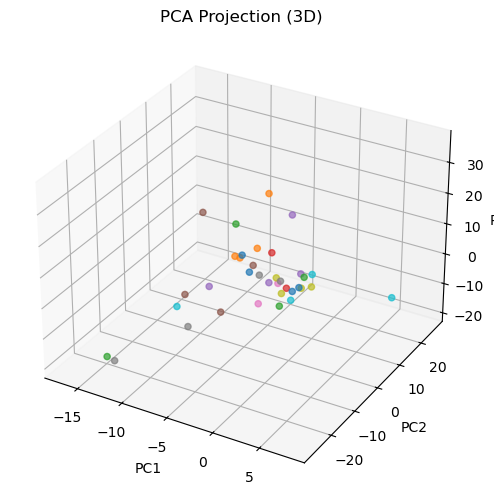

In [29]:
from mpl_toolkits.mplot3d import Axes3D

fig = plt.figure(figsize=(8,6))
ax = fig.add_subplot(111, projection='3d')

ax.scatter(
    X_test_pca[:,0],
    X_test_pca[:,1],
    X_test_pca[:,2],
    c=y_test,
    cmap='tab10',
    alpha=0.7
)

ax.set_xlabel("PC1")
ax.set_ylabel("PC2")
ax.set_zlabel("PC3")
plt.title("PCA Projection (3D)")
plt.show()

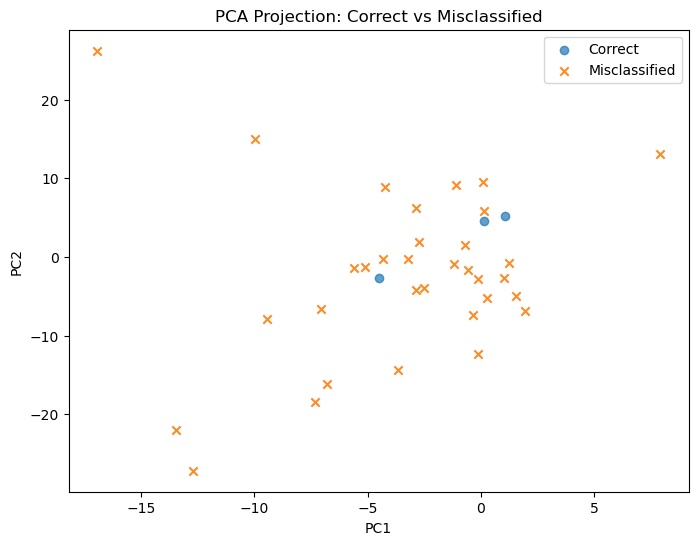

In [46]:
# Get PCA-transformed test data
X_test_scaled = clf_reduced.named_steps['scaler'].transform(X_test)
X_test_pca = clf_reduced.named_steps['pca'].transform(X_test_scaled)

correct = (y_pred == y_test)

plt.figure(figsize=(8,6))
plt.scatter(
    X_test_pca[correct, 0], X_test_pca[correct, 1],
    alpha=0.7, label="Correct", marker='o'
)
plt.scatter(
    X_test_pca[~correct, 0], X_test_pca[~correct, 1],
    alpha=0.9, label="Misclassified", marker='x'
)
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.title("PCA Projection: Correct vs Misclassified")
plt.legend()
plt.show()

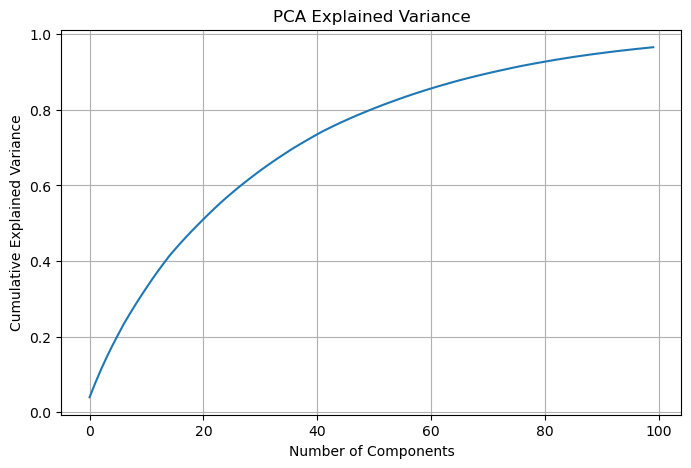

In [30]:
plt.figure(figsize=(8,5))
plt.plot(clf_reduced.named_steps['pca'].explained_variance_ratio_.cumsum())
plt.xlabel("Number of Components")
plt.ylabel("Cumulative Explained Variance")
plt.title("PCA Explained Variance")
plt.grid()
plt.show()

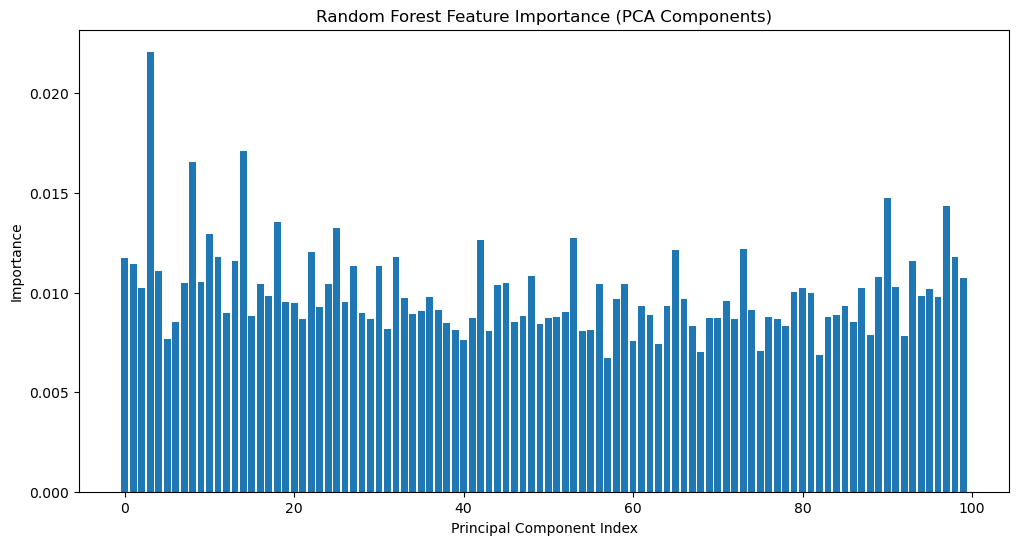

In [32]:
importances = clf_reduced.named_steps['rf'].feature_importances_

plt.figure(figsize=(12,6))
plt.bar(range(len(importances)), importances)
plt.title("Random Forest Feature Importance (PCA Components)")
plt.xlabel("Principal Component Index")
plt.ylabel("Importance")
plt.show()


In [34]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score
clf = DecisionTreeClassifier(random_state=42)

# Train model
clf.fit(X_train, y_train)

# Predict
y_pred = clf.predict(X_test)

# Accuracy
print("Accuracy:", accuracy_score(y_test, y_pred))

Accuracy: 0.2222222222222222


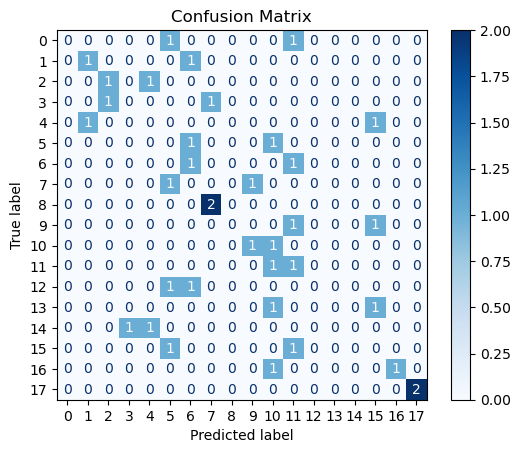

In [35]:
ConfusionMatrixDisplay.from_predictions(y_test, y_pred, cmap='Blues')
plt.title("Confusion Matrix")
plt.show()

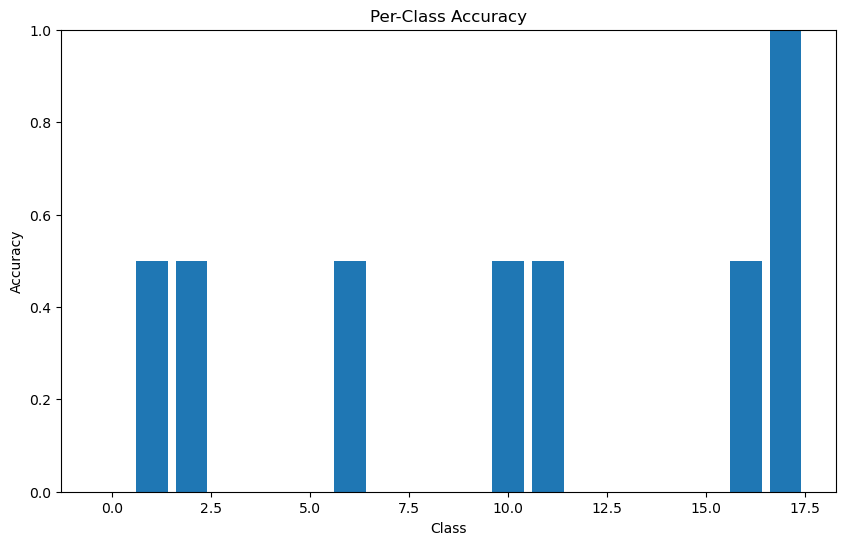

In [39]:
import numpy as np

classes = np.unique(y_test)
accuracies = [
    (y_pred[y_test == c] == c).mean()
    for c in classes
]

plt.figure(figsize=(10,6))
plt.bar(classes, accuracies)
plt.ylim(0,1)
plt.title("Per-Class Accuracy")
plt.xlabel("Class")
plt.ylabel("Accuracy")
plt.show()


In [52]:

from sklearn.svm import SVC
# Create SVM model
clf = SVC(kernel="rbf", C=1.0, gamma="scale")  # default RBF kernel

# Train
clf.fit(X_train, y_train)

# Predict
y_pred = clf.predict(X_test)
y_proba = clf_reduced.predict_proba(X_test)  # for probability-based plots
classes = clf_reduced.named_steps['rf'].classes_
# Accuracy
print("Accuracy:", accuracy_score(y_test, y_pred))

Accuracy: 0.08333333333333333


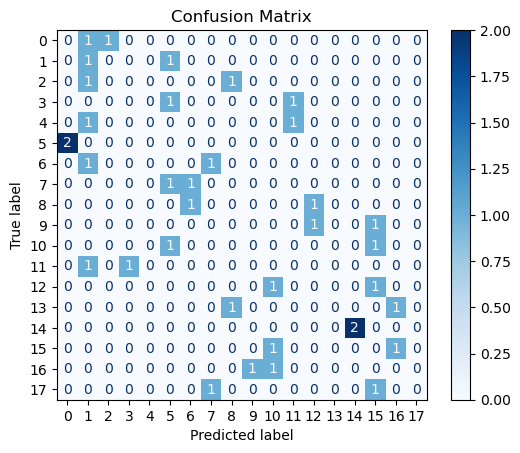

In [41]:
ConfusionMatrixDisplay.from_predictions(y_test, y_pred, cmap='Blues')
plt.title("Confusion Matrix")
plt.show()

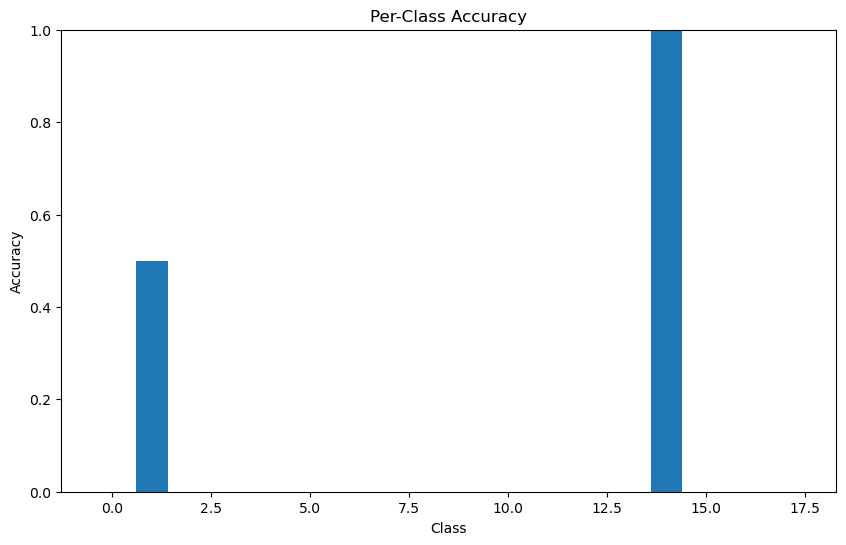

In [43]:

classes = np.unique(y_test)
accuracies = [
    (y_pred[y_test == c] == c).mean()
    for c in classes
]

plt.figure(figsize=(10,6))
plt.bar(classes, accuracies)
plt.ylim(0,1)
plt.title("Per-Class Accuracy")
plt.xlabel("Class")
plt.ylabel("Accuracy")
plt.show()

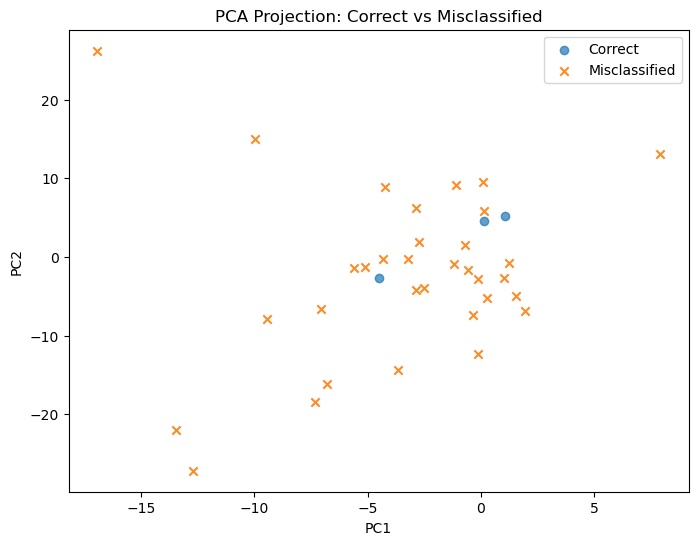

In [53]:
# Get PCA-transformed test data
X_test_scaled = clf_reduced.named_steps['scaler'].transform(X_test)
X_test_pca = clf_reduced.named_steps['pca'].transform(X_test_scaled)

correct = (y_pred == y_test)

plt.figure(figsize=(8,6))
plt.scatter(
    X_test_pca[correct, 0], X_test_pca[correct, 1],
    alpha=0.7, label="Correct", marker='o'
)
plt.scatter(
    X_test_pca[~correct, 0], X_test_pca[~correct, 1],
    alpha=0.9, label="Misclassified", marker='x'
)
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.title("PCA Projection: Correct vs Misclassified")
plt.legend()
plt.show()

In [60]:

from sklearn.linear_model import LogisticRegression
# Create Logistic Regression model
clf = LogisticRegression(max_iter=1000)

# Train
clf.fit(X_train, y_train)

# Predict
y_pred = clf.predict(X_test)

# Accuracy
print("Accuracy:", accuracy_score(y_test, y_pred))

Accuracy: 0.1111111111111111


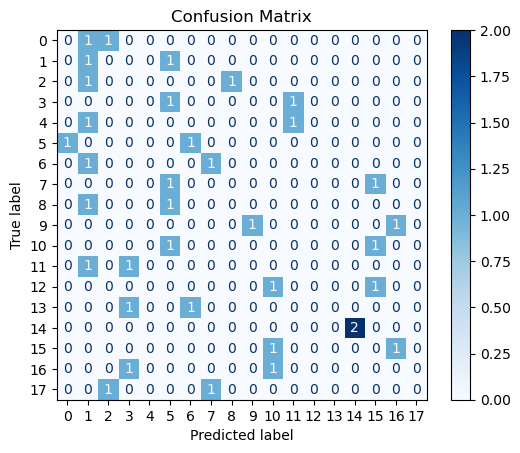

In [61]:
ConfusionMatrixDisplay.from_predictions(y_test, y_pred, cmap='Blues')
plt.title("Confusion Matrix")
plt.show()

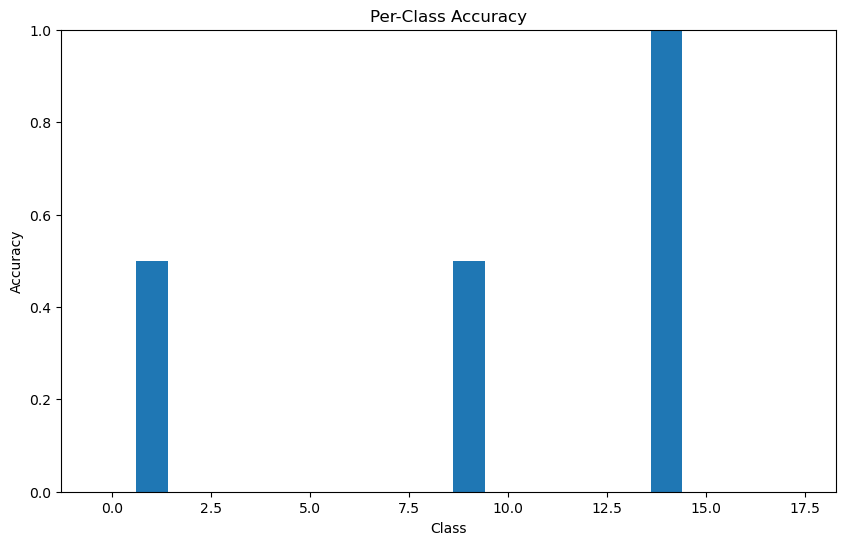

In [62]:
classes = np.unique(y_test)
accuracies = [
    (y_pred[y_test == c] == c).mean()
    for c in classes
]

plt.figure(figsize=(10,6))
plt.bar(classes, accuracies)
plt.ylim(0,1)
plt.title("Per-Class Accuracy")
plt.xlabel("Class")
plt.ylabel("Accuracy")
plt.show()